## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [64]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc

from trajopt.analysis.trajplots import *

from custom_functions_dan import max_q_nonjax, max_Q_nonjax, max_load_nonjax, terminal_cost



setup problem and run SCP

In [65]:
example_name = "vtol1_entry_3dof"
nominal_config  = cfg.load_configs(example_name)

# either generate mc variations from yamls or load existing saved mc variations
gen_mc_variations    = 1

# save mc variations to file (specificy a name for this set of mc variations as well)
save_mc_variations   = 0
mc_name = "mc1"

# save scenario data to file (save the scenario data struct)
save_scenario_data   = 0

# run mc analysis loop
# TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name)

scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
Initial guess time: 0.12504116701893508 seconds
Cost initial: 0.11051444205607251
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------

mc analysis

In [66]:
# file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# Can run without filename if you don't want to save LaTeX tables
analysis = stats.analyze_quality_metrics(scenario_data)

Extracting data from runs...
Computing statistics across runs...
Generating statistic tables...
Plotting tables...

=== No. of Iteration ===

         standard   autotune
Max     15.000000  26.000000
Mean    10.500000  21.500000
Median  10.500000  21.500000
Min      6.000000  17.000000
Mode     6.000000  17.000000
Std      6.363961   6.363961
Var     40.500000  40.500000


=== Solve Time/Iteration (ms/iter) ===

        standard   autotune
Max     8.896669  13.693390
Mean    8.520976  10.645804
Median  8.520976  10.645804
Min     8.145284   7.598218
Mode    8.145284   7.598218
Std     0.531309   4.309938
Var     0.282290  18.575565


=== Parse Time/Iteration (ms/iter) ===

            standard    autotune
Max       295.391162  106.935361
Mean      208.867629   91.135748
Median    208.867629   91.135748
Min       122.344097   75.336135
Mode      122.344097   75.336135
Std       122.362754   22.344027
Var     14972.643480  499.255526


=== Propagation Time/Iteration (ms/iter) ===

      

# Load data and preprocess... (compute loads...)

In [67]:
from plots_for_scitech26 import *
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
preProcess(PLTS1,problem);
    

# DASHBOARD

In [68]:
versions = ['standalone','sa_iters','methodvar','montecarlo','mvmc'];
figpaths = ['figs/standalone/','figs/standalone/','figs/methodvar/','figs/methodvar/','figs/montecarlo/'];

displayfigs = True;
printfigs = False; 
transparentfigs = True; 

specs = {}
specs['standalone'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['sa_iters'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard','autotune'],'runs':list(range(1000))[1:]}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

plotparams = {};
plotparams['problem'] = problem
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



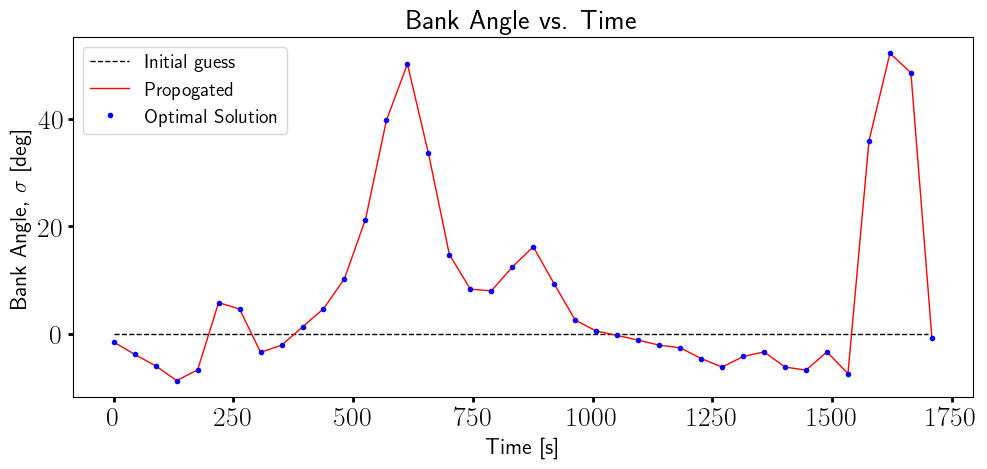

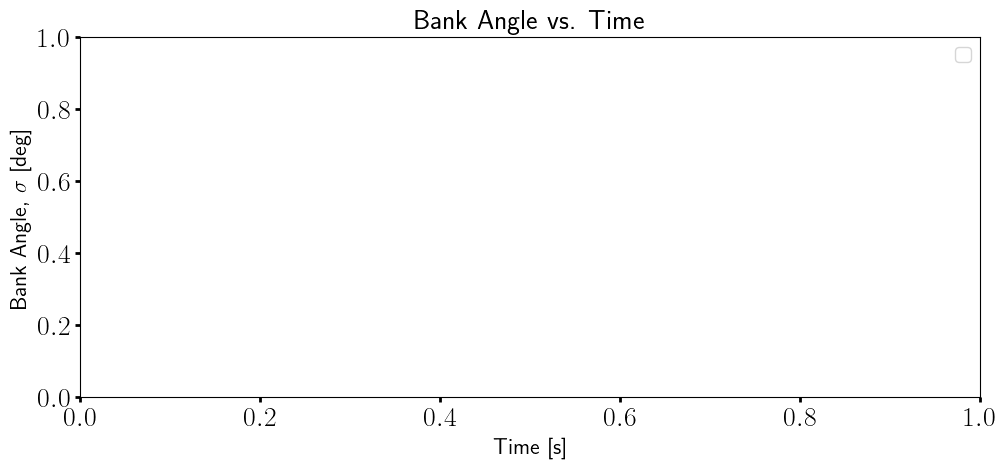

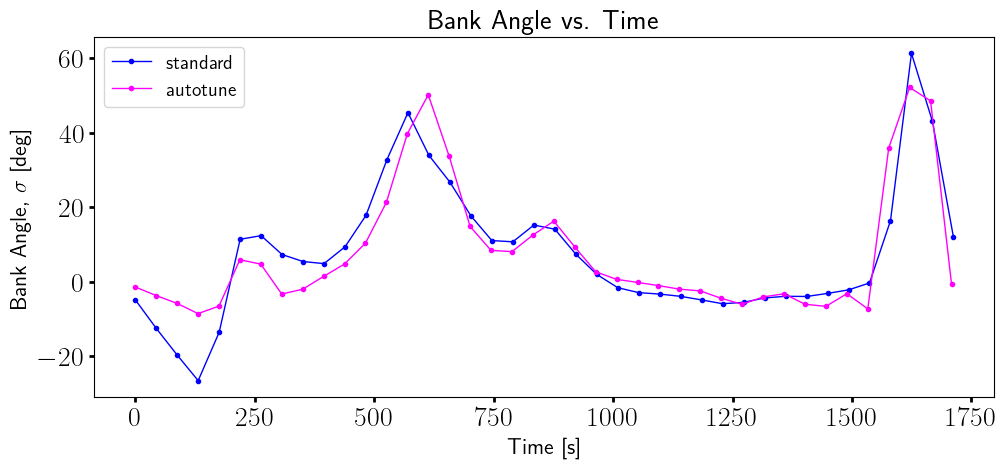

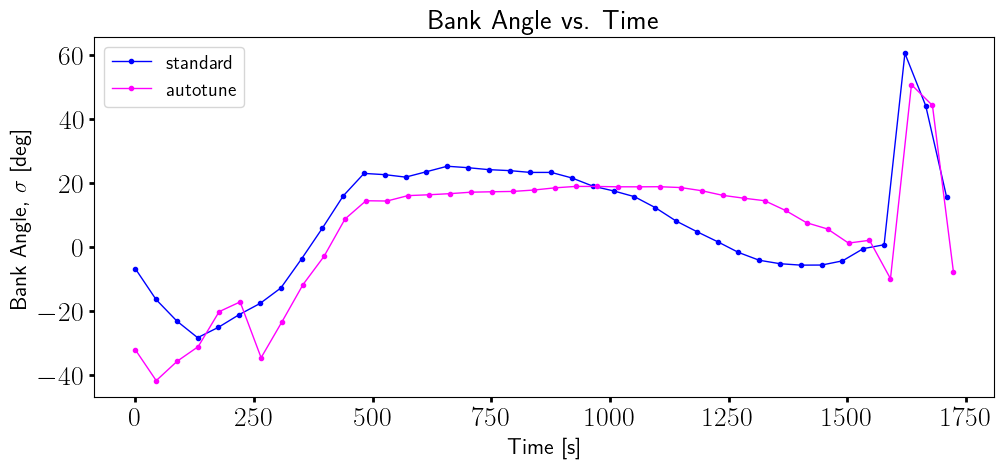

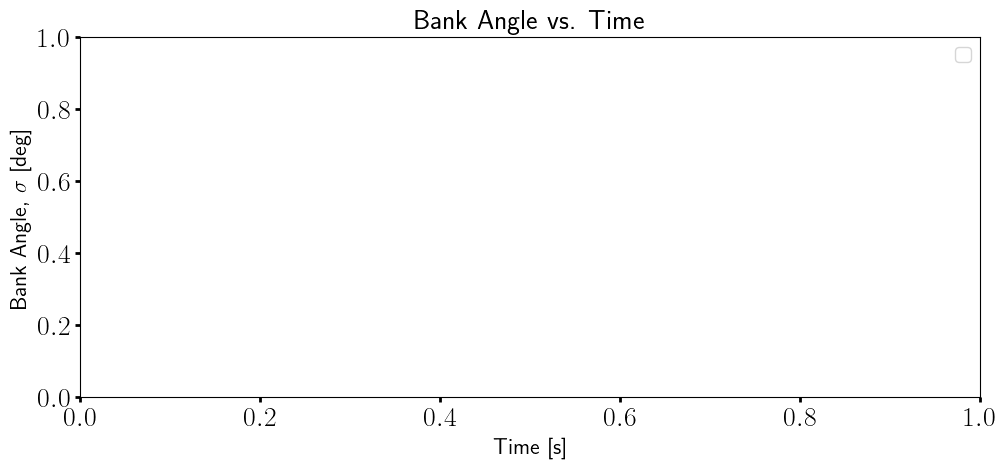

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

...

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

In [7]:
makePlotWghts(PLTS1,ins=plotparams);
# makePlotWghts2(PLTS1,ins=plotparams);
makePlotConvs(PLTS1,ins=plotparams);
makePlotConvs2(PLTS1,ins=plotparams);

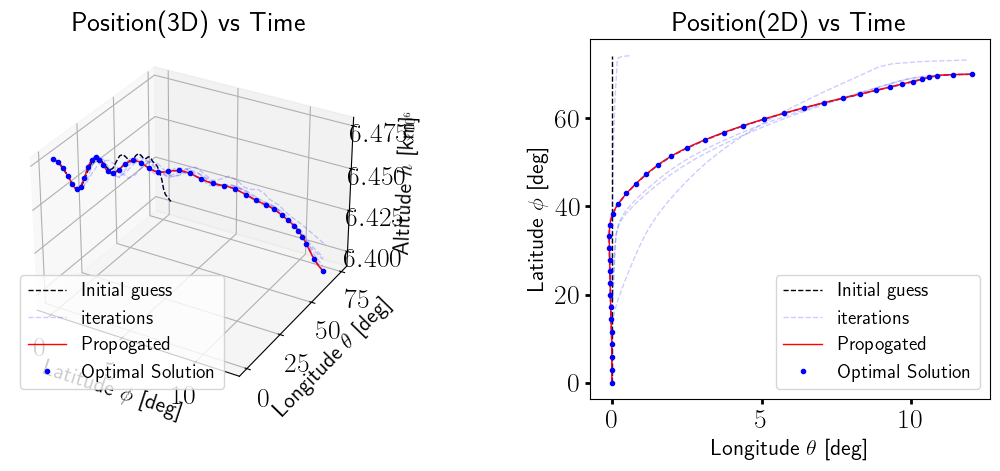

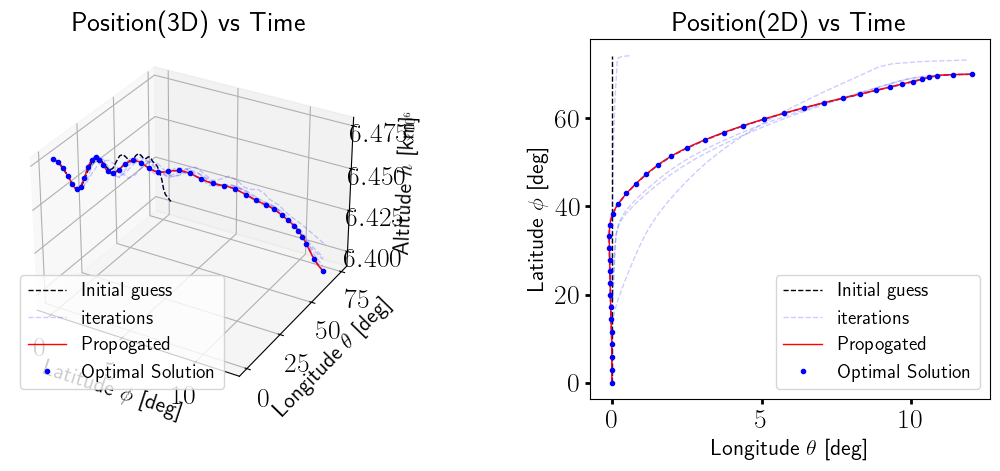

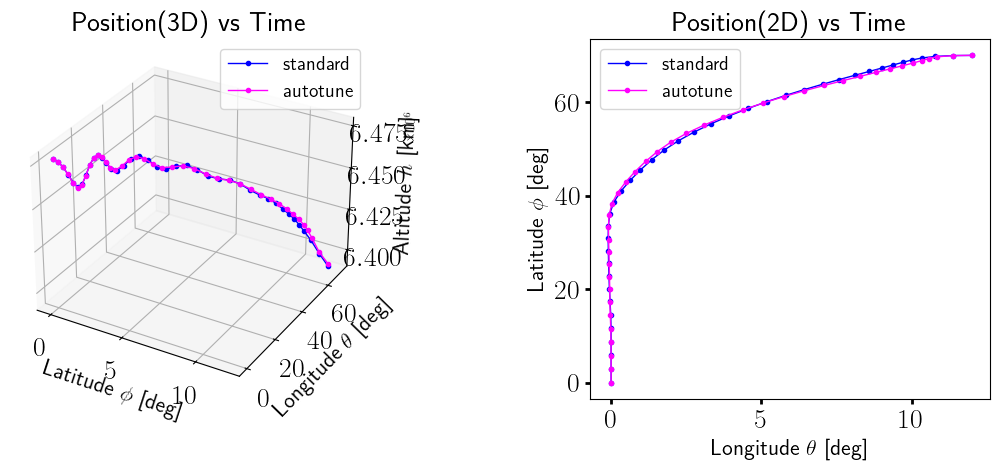

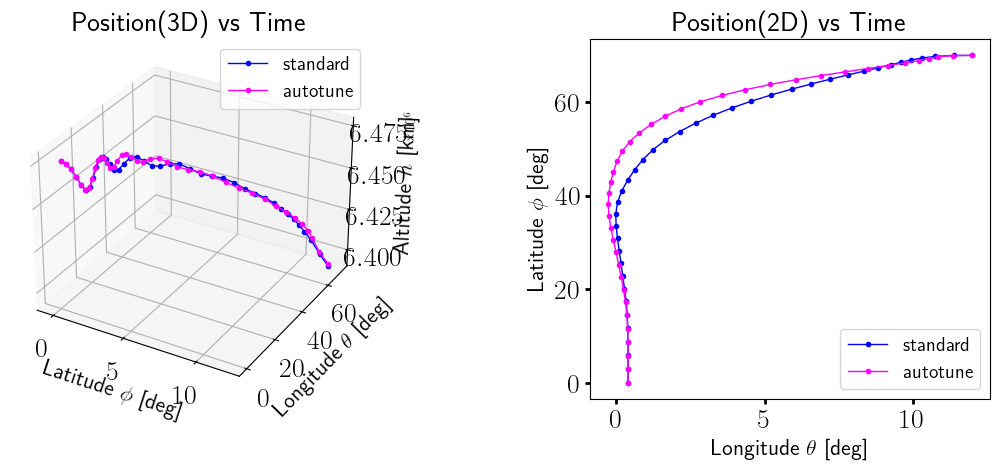

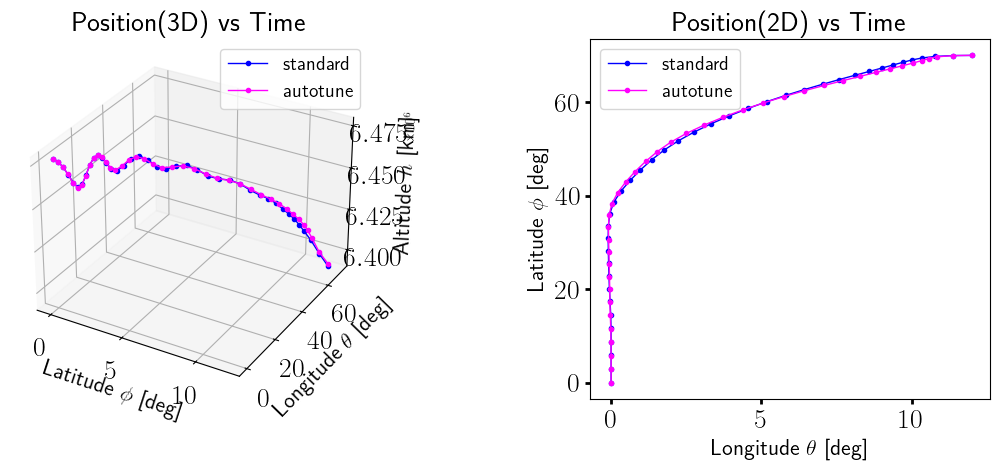

In [77]:
params = {}
params['displayfigs'] = True;
makePlotTrajs(PLTS1,ins={**plotparams,**params});

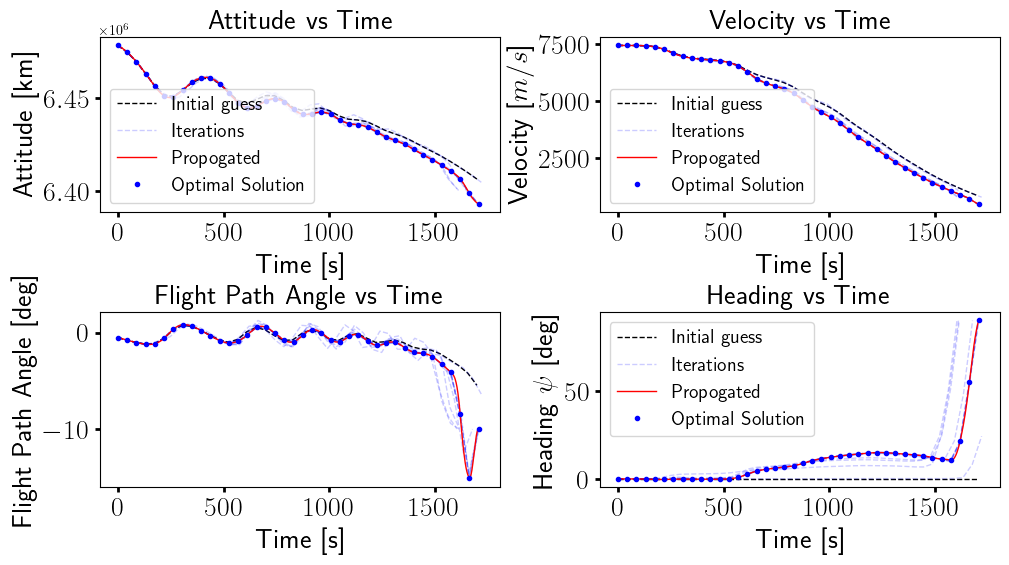

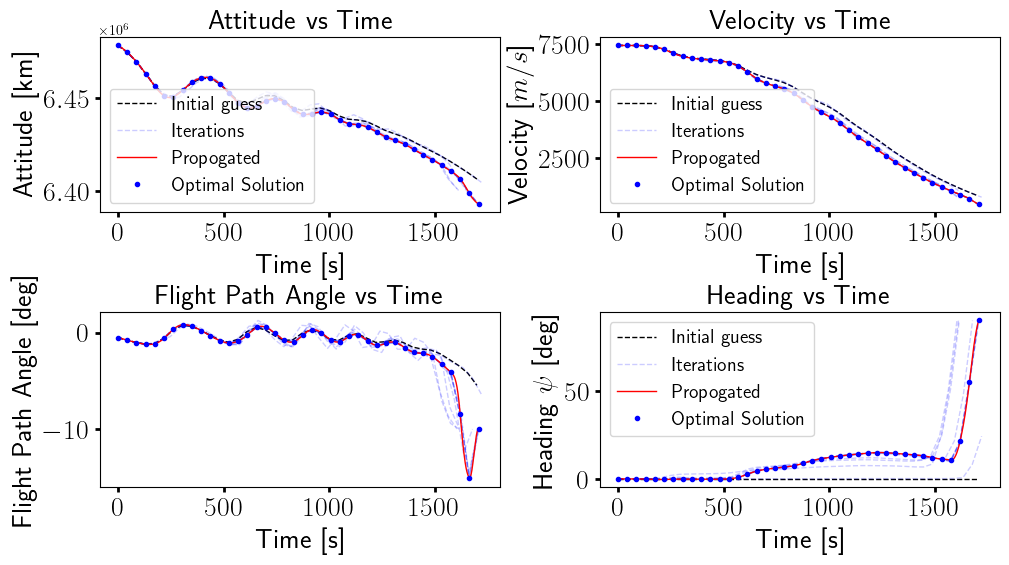

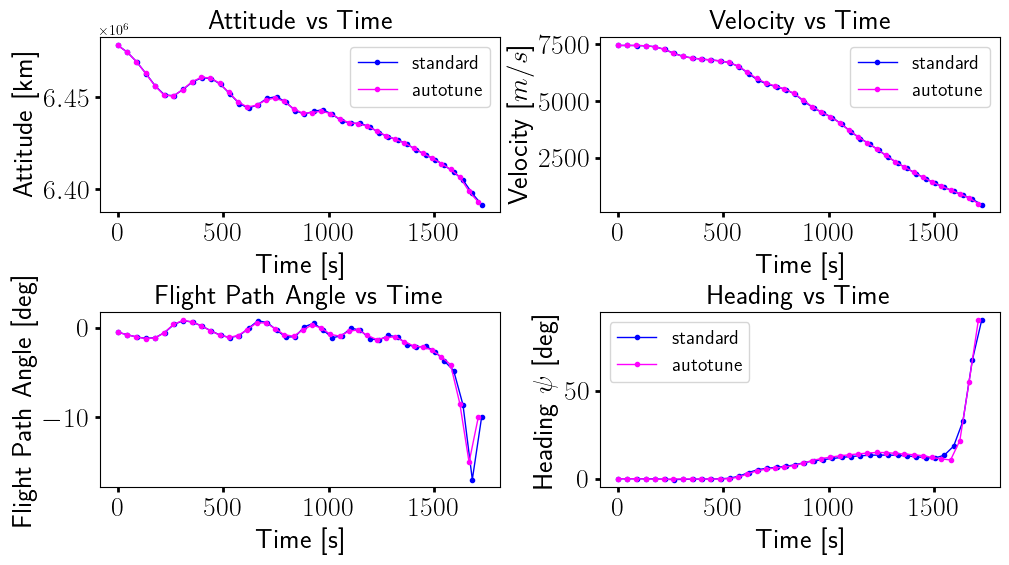

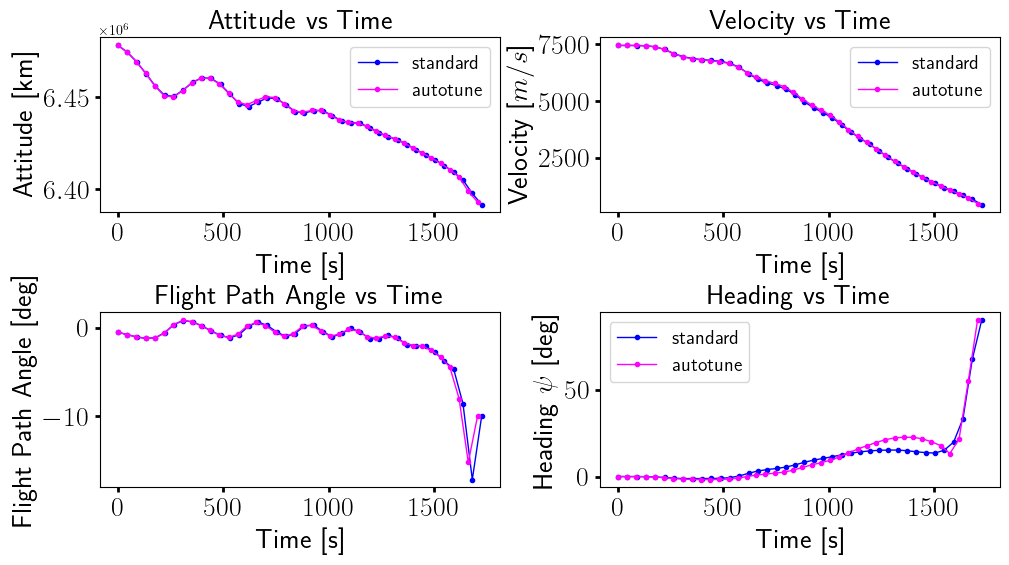

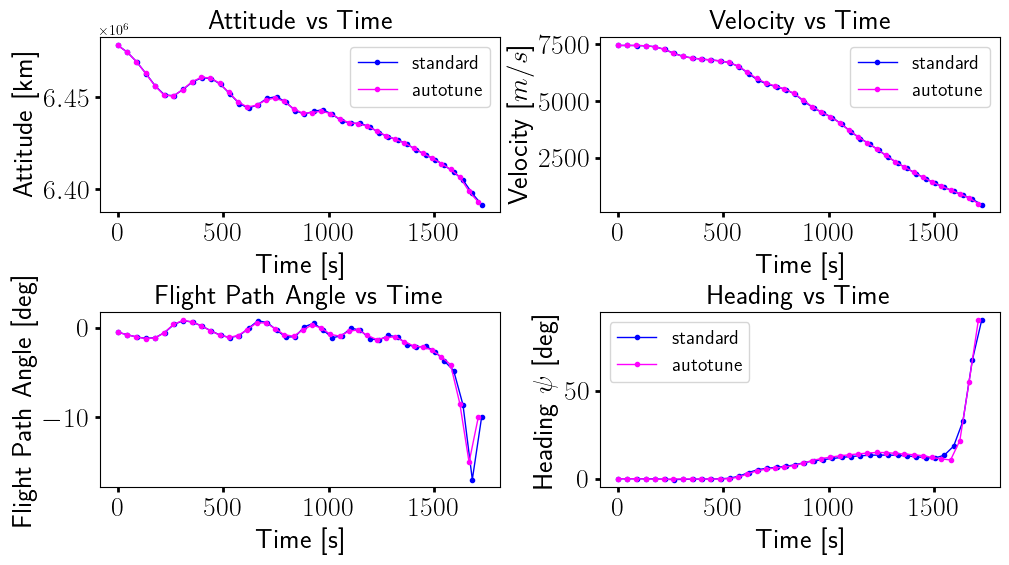

In [78]:
params = {}
figsize = (10,5);
grid = {};
grid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];
grid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];
   
titles = {};
ylabels = {};
xlabels = {ind:'Time [s]' for ind in range(4)};
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';

ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';    
ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';

params['titleinfo'] = {'fontsize':20,}
params['xlabelinfo'] = {'fontsize':20}
params['ylabelinfo'] = {'fontsize':20}
# params['ticksinfo'] = {'fontsize':20}
# params['legendinfo'] = {'fontsize':2}
params['uselegend'] = [0,1,3];

params['figsize'] = figsize; params['grid'] = grid;
params['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;
params['displayfigs'] = True;

makePlotStates(PLTS1,ins={**plotparams,**params});

In [79]:
# temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['weights'];#params']['method']['weights']['W_dyn'];
temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['conv_data'];#['chk_feas_ineq'];#params']['method']['weights']['W_dyn'];
# ['w_cost', 'alpha_z', 'alpha_u', 'beta', 'gamma', 'eps_nonzero1',
#  'eps_nonzero2', 'wbuff', 'w_path_scale', 'w_custom_scale', 'w_nfz_scale',
#  'w_dyn_scale', 'w_term_scale',

#  'W_ineq', 'W_term', 'W_dyn', 'W_plus','W_minus',
#  'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus',

#  'wtr_z', 'wtr_u', 'w_fac_N', 'w_fac_Nm1', 'w_ctcs', 'data']


# print(temp)
# print(list(temp))
# print(temp['W_ineq'])

In [80]:

temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(temp['weights']['W_ineq'])
print(temp['W_ineq'].shape)
inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# plt.plot(temp['W_ineq'][:,inds])

(40, 5)


In [81]:
# temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(list(temp))# print(temp['weights']['W_ineq'])
# print(temp['W_minus_ctcs'])
# print(temp['W_ineq'].shape)
# inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# # plt.plot(temp['W_ineq'][:,inds])

# temp = problem.method.subprob.iter_data[0]['conv_data']

# # print(list(PLTS1.data['scenario1']['method']))

# print(list(temp))
# print(temp['chk_feas_term'])